# Week 4 - Probability Distributions 3 and Mixture Models

Learning contents:

1. Histogram-based density estimation
    - Display histogram densities
2. Kernel density estimation
    - Hypercube Kernel function
    - Gaussian Kernel function
3. K-Nearest Neigbours classification
    - Generate data
    - Classification function
    - Display results
4. K-Means clustering
    - Display results

## Dependencies

In [782]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from math import sqrt
from collections import Counter
from scipy.stats import norm
from sklearn import datasets
from IPython.display import HTML
from math import floor
from itertools import islice 
import seaborn as sns; sns.set(); sns.set_palette('bright')

## Kernels

In [783]:
def kernel_density(x, data, h, kernel): 
    """
    Den generelle formel for sandsynlighedsfordelingen. \n
    p(x) = 1/N * 1/(h^D) * ∑ k((x - mu)/h)
    
    Args:
        x (float): Er et enkelt datapunkt.
        data (np.array): Mit træningsdata som jeg vil sammenligne x med.
        h (float): "Båndbredden", bestemmer afstanden væk fra x af datapunkter som er relevante.

    Returns:
        px (float): Sandsynligheden
    """
    xn = np.array(data)
    if xn.ndim == 1: 
        N = len(xn)
        D = 1
    else: 
        N, D = xn.shape
    px = (1/N) * (1 / (h ** D)) * np.sum(kernel((x - xn)/h))
    return px

### Funktioner

In [784]:
def kernel_gaussian(u):
    r"""
    Gaussisk kernel
    Forventer u = (x - mu)/h da vil funktionen returnere sandsynligheden ud fra summen af normalfordelingerne som x passer ind i. 
    ```
    |
    |                 x
    |                 |
    |       __---__   |   __---__               __---__
    |      /   |   \  v  /   |    \            /   |   \
    |     |    |    |_ _|    |     |          |    |    |
    |    /     |      |      |      \        /     |     \
    |_--|     x_0           x_1      |--__--|     x_2     |--___
    ```

    Skriver funktionen som en general gaussian funktion
    1/2 * ( x - mu)^2 / (sig^2 ) = 1/2 * ((x - mu) / sig)^2 
        
    Og det passer med den måde jeg plejer at indsætte i kernels på k((x - mu)/h)
    """
    D = u.ndim
    px_norm = (1/((2*np.pi) ** (D/2))) * np.exp(-1/2 * (u**2)) 
    return px_norm

def kernel_hypercube(u):
    """
    Givet et datasæt, brug de punkter som ligger indenfor en afstand af 0.5 til at fortælle om dens sandsynlighed.
    Forventer u = (x - mu)/h da vil funktionen returnere: 
    ```
    |
    |
    |
    |   x_1 
    | x_0 
    |    x_2
    |       x_3
    |             x_4
    |                     x_5
    |                             x_6
    |         |-------x-------|
    |
    |          <-0.5h->
    |_________________________________
    ```
    (x - x_n)/h = 0.5 -> x - x_n = 0.5h
    
    (x - x_n)/h = [0, 0, 0, 0, 1, 1, 0]
    """
    return np.array([1 if np.abs(i) <= 1/2 else 0 for i in u])

### Displays

In [785]:
def display_kernel_density(data, h, kernel, color='b'):
    xs = np.linspace(min(data), max(data), 200)
    ys = np.array([kernel_density(x, data, h, kernel) for x in xs])
    plt.plot(xs, ys, '-' + color, label='h=' + str(h))
    plt.legend()

## Generate data

write a function `generate_data_1D` that returns `n` realizations of a single random variable exhibiting mixture of Gaussian distribution with parameters `means`, `variances` and `pi`.

In [786]:
def generate_data_1D(size, means, variances, pi):
    x=[]
    np.random.seed(10)
    for i in range(size):
        z_i = np.argmax(np.random.multinomial(1, pi))
        x_i = np.random.normal(means[z_i], variances[z_i]) 
        x.append(x_i) 
    return x

The function below generates 1000 data points from the Gaussian mixture distribution and plots their histogram. Observe the plot and comment on whether the plot coincides with the input data.

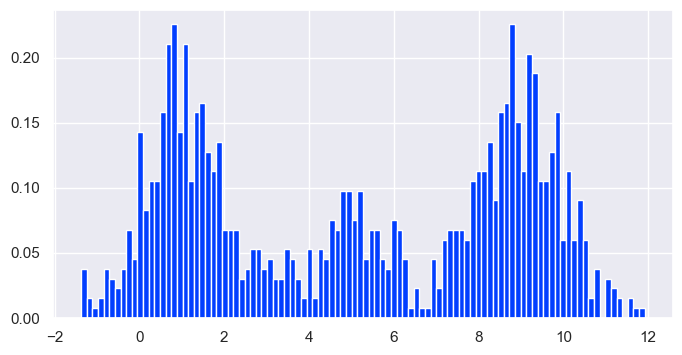

In [787]:
means = [1, 5, 9]
variances = [1, 1, 1]
pis = [0.4, 0.2, 0.4]
data = generate_data_1D(1000, means, variances, pis);
fig, ax = plt.subplots(figsize=(8, 4));
ax.hist(data, bins=100, density=True);

## 1) Histogram-based density estimation

write a function `histogram` that takes input `data`, user-defined bin size `delta` and returns `bins` (list of edges of the bins) and their corresponding `probabilities`. Hint: you can use numpy's histogram function to do so.

1.0
1.0


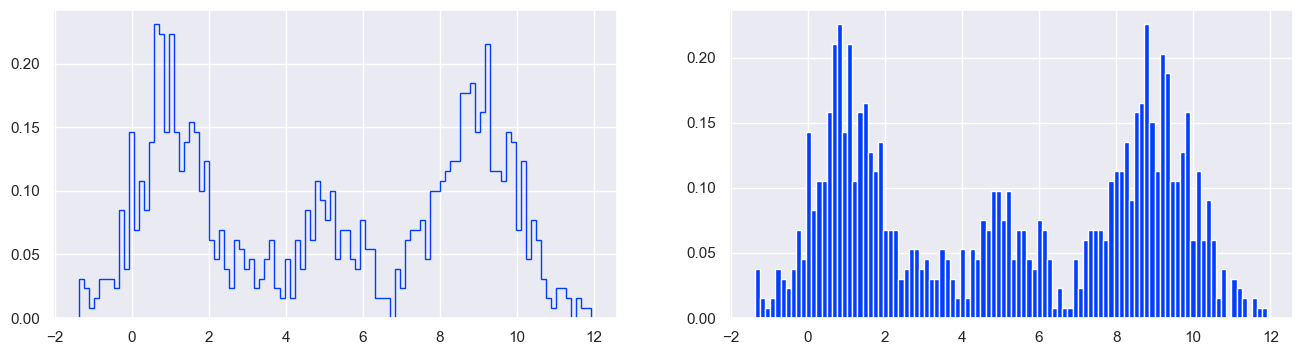

In [788]:
def histogram(data, delta):
    #  ___
    # |   |    ___
    # |   |___|   |
    # |   |   |   |
    # |___|___|___|
    # 
    # | ∆ |
    
    # Fordelingen bliver lavet ud fra antallet af data som kan blive lagt i de her kasser.
    # 0*∆<= x < ∆,  1*∆<= x < 2∆,  ....
    
    # Når man så har konstrueret den, så har jeg, at en ny sandsynlighed er. Eks. ∆ = 8, Histogram = [7, 4, 5]
    #        ___
    #       |   |    ___
    #       |   |___|   |
    #       |   |   |   |
    #       |___|___|___|
    #         ^ 
    # p(4) =  |
    # p(4) = n_bin_1 / (N * ∆)
    # p(4) = 7 / ((7 + 4 + 5) * 8) 
    # p(4) = 7 / (136)  
    dataKategoriseret = np.array([x // delta for x in data])    # floor(21 / 4) = 5 
    minval = np.abs(np.min(dataKategoriseret))
    dataKategoriseret += minval                                 # Nogle bins er på den negative side af y aksen. Bincount virker kun for positive tal
    bins = np.bincount(np.int64(dataKategoriseret))
    edges1 = np.array([i * delta for i in range(len(bins))])
    edges1 -= minval * delta
    N = np.sum(bins)
    p = bins/(N * delta)
    print(np.sum(p) * delta)    # = 100% 
    # Ideen var god, men det passer ikke helt.
    
    
    # Numpy's metode.
    dVals = np.max(data) - np.min(data)
    ni, edges2 = np.histogram(data, np.int64(dVals // delta))
    p = ni / (N * delta)
    print(np.sum(p) * delta)            # = 100% 
    
    return (edges2, p)
    
edges, p = histogram(data, 13/100)
fig, ax = plt.subplots(1, 2, figsize = (16, 4))
ax[1].hist(data, bins=100, density=True)
ax[0].stairs(p, edges)

# Det ligner meget godt


### 1.1) Display histogram densities

Display the `histograms` for different values of bin sizes and also compute and plot the `true` probability density (slide 9 of lecture 7) of the data. Compare the two plots and see which values of bin sizes reveal densities that are close to the true density function

In [789]:
def univariate_normal(x, mean, variance):
    return ((1. / np.sqrt(2 * np.pi * variance)) * np.exp(-(x - mean)**2 / (2 * variance)))

def display_histogram_density(data, delta):
    bins, probs = histogram(data, delta)

    a = np.arange(-5, 15, 0.01)
    y = pis[0] * univariate_normal(a, mean=means[0], variance=variances[0]**2) + pis[1] * univariate_normal(a, mean=means[1], variance=variances[1]**2)+ pis[2] * univariate_normal(a, mean=means[2], variance=variances[2]**2)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(bins[:-1],probs,width=0.1)
    ax.plot(a, y,'-r')

1.0
1.0


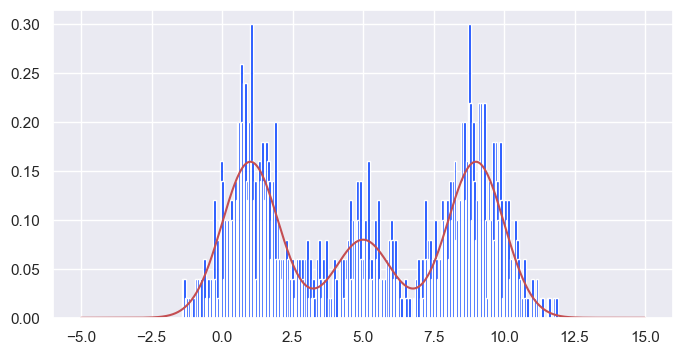

In [790]:
display_histogram_density(data, 0.05)

1.0
1.0


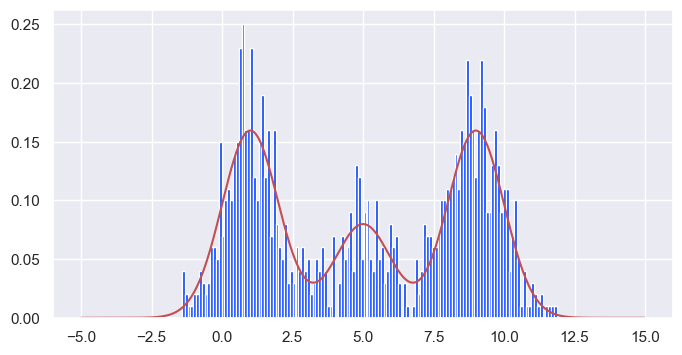

In [791]:
display_histogram_density(data, 0.1)

1.0
1.0


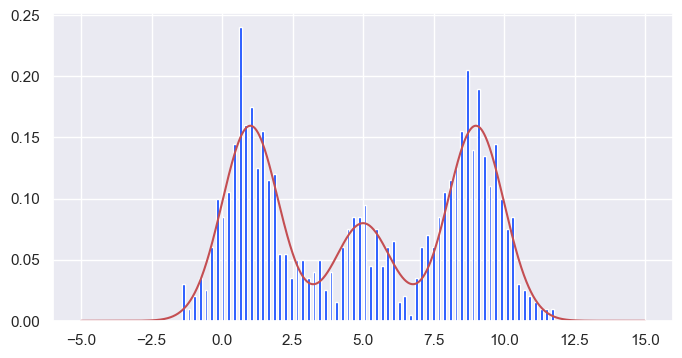

In [792]:
display_histogram_density(data, 0.2)

1.0
1.0


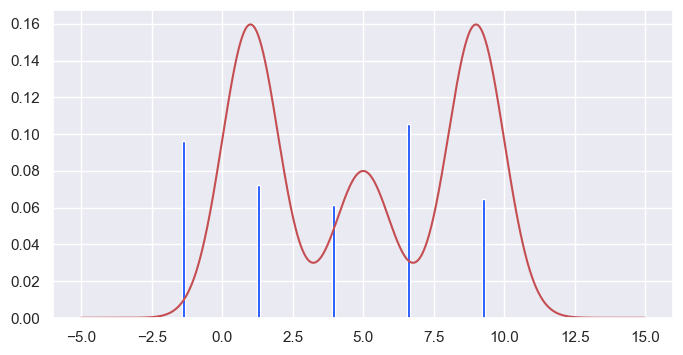

In [793]:
display_histogram_density(data, 2.5)

## 2) Kernel density estimation ( Specifik metode)

### 2.1) Hypercube Kernel function

write a function `hypercube_kernel_function` takes `u` and returns 0 or 1 if `u` is inside 1/2 hypercube (see slide 18 of lecture 7).

In [794]:
def hypercube_kernel_function(u):
    """
    Givet et datasæt, brug de punkter som ligger indenfor en afstand af 0.5 til at fortælle om dens sandsynlighed.
    Forventer u = (x - mu)/h da vil funktionen returnere: 
    ```
    |
    |
    |
    |   x_1 
    | x_0 
    |    x_2
    |       x_3
    |             x_4
    |                     x_5
    |                             x_6
    |         |-------x-------|
    |
    |          <-0.5h->
    |_________________________________
    ```
    (x - x_n)/h = 0.5 -> x - x_n = 0.5h
    
    (x - x_n)/h = [0, 0, 0, 0, 1, 1, 0]
    """
    return np.array([1 if np.abs(i) <= 1/2 else 0 for i in u])

write the function `hypercube_kernel_density` that takes a single data point `x`, training data points `data`, size of a cube `h`, data dimensions `D` and returns the probability density of `x` based on the Hypercube kernel function (see the first equation on slide 19 of lecture 7)

In [795]:
def hypercube_kernel_density(x, data, h, D):
    # Sandsynlighed på mit kernel funktion.
    # ∑(x - x_n)/h = ∑([0, 0, 0, 0, 1, 1, 0]) = 2
    # p(x) = 1/6 * 1/(h**d) * 2
    xn = data
    N = len(data)
    p = (1/N) * (1 / (h ** D)) * np.sum(hypercube_kernel_function((x - xn)/h))
    return p


display the computed nonparametric density estimates for different values of `h`. What is the effect of `h` on density estimates?

In [796]:
def display_hypercube_kernel_density_1D(data, h, color='b'):
    xs = np.linspace(min(data), max(data), 200)
    plt.plot(xs, list(map(lambda x: hypercube_kernel_density(x, data, h, 1), xs)), '-' + color, label='h=' + str(h))
    plt.legend()

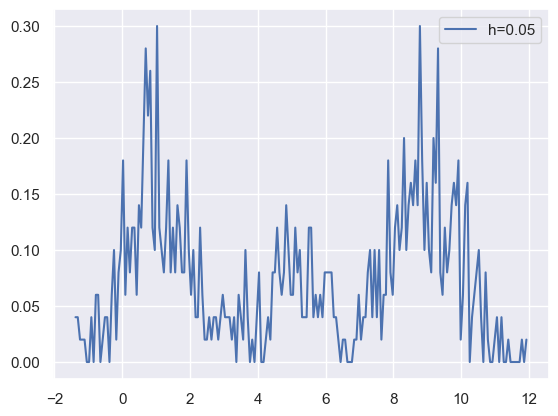

In [797]:
display_hypercube_kernel_density_1D(data, 0.05, 'b')

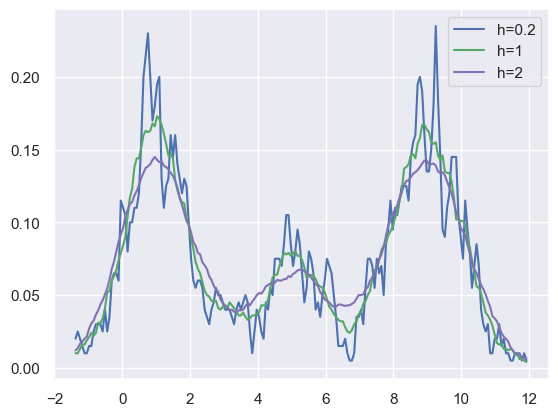

In [798]:
display_hypercube_kernel_density_1D(data, 0.2, 'b')
display_hypercube_kernel_density_1D(data, 1, 'g')
display_hypercube_kernel_density_1D(data, 2, 'm')

### 2.2) Gaussian Kernel function

Write the function `gaussian_kernel_function` that takes pair of points `x` and `x_n`, size `h` and returns Gaussian kernel function value for the pair of points.

In [799]:
def gaussian_kernel_function(u):
    r"""
    Gaussisk kernel, forventer k((x - mu)/h), da findes sandsynligheden ud fra summen af normalfordelingerne.
    ```
    |
    |                 x
    |                 |
    |       __---__   |   __---__               __---__
    |      /   |   \  v  /   |    \            /   |   \
    |     |    |    |_ _|    |     |          |    |    |
    |    /     |      |      |      \        /     |     \
    |_--|     x_0           x_1      |--__--|     x_2     |--___
    ```

    Skriver funktionen som en general gaussian funktion
    1/2 * ( x - mu)^2 / (sig^2 ) = 1/2 * ((x - mu) / sig)^2 
        
    Og det passer med den måde jeg plejer at indsætte i kernels på k((x - mu)/h)
    """
    D = u.ndim
    px_norm = (1/((2*np.pi) ** (D/2))) * np.exp(-1/2 * (u**2)) 
    return px_norm

Write the `gaussian_kernel_density` function that takes any point `x`, training data points `data`, size `h` and returns the Gaussian kernel density value for the point `x` (see the last equation in slide 19 of lecture 7)

In [800]:
def gaussian_kernel_density(x, data, h):
    xn = np.array(data)
    if xn.ndim == 1: 
        N = len(xn)
        D = 1
    else: 
        N, D = xn.shape
    px = (1/N) * (1 / (h ** D)) * np.sum(gaussian_kernel_function((x - xn)/h))
    return px
    

In [801]:
def display_gaussian_kernel_density_1D(data, h, color='b'):
    xs = np.linspace(min(data), max(data), 200)
    plt.plot(xs, list(map(lambda x: kernel_density(x, data, h, kernel_gaussian), xs)), '-' + color, label='h=' + str(h))
    plt.legend()

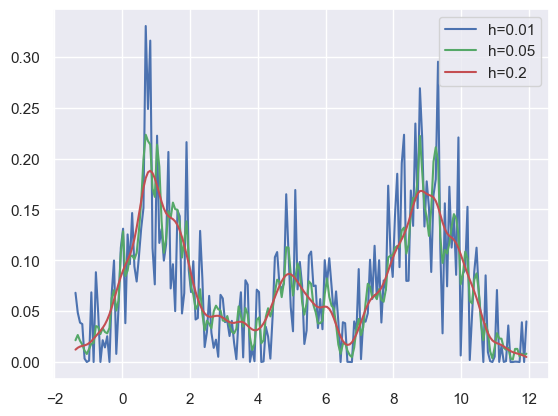

In [802]:
display_gaussian_kernel_density_1D(data, 0.01, 'b')
display_gaussian_kernel_density_1D(data, 0.05, 'g')
display_gaussian_kernel_density_1D(data, 0.2, 'r')

## 2) Kernel density estimation (General metode)

### Displays 

In [803]:
def display_kernel_density(data, h, kernel, color='b'):
    xs = np.linspace(min(data), max(data), 200)
    ys = np.array([kernel_density(x, data, h, kernel) for x in xs])
    plt.plot(xs, ys, '-' + color, label='h=' + str(h))
    plt.legend()

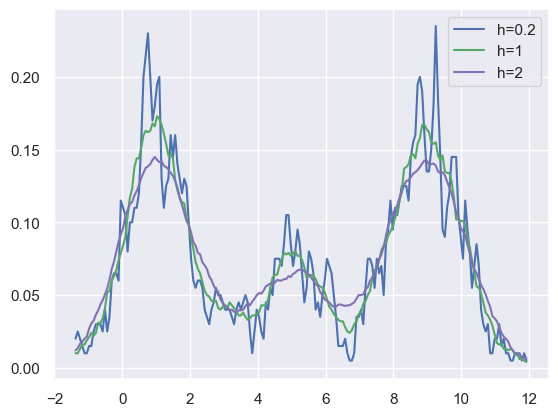

In [804]:
display_kernel_density(data, 0.2, kernel_hypercube, 'b')
display_kernel_density(data, 1, kernel_hypercube, 'g')
display_kernel_density(data, 2, kernel_hypercube, 'm')

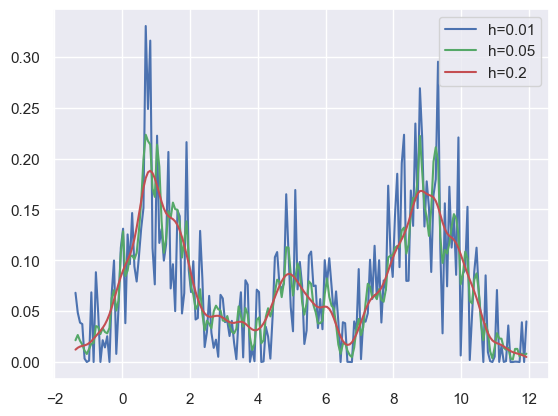

In [805]:
display_kernel_density(data, 0.01, kernel_gaussian, 'b')
display_kernel_density(data, 0.05, kernel_gaussian, 'g')
display_kernel_density(data, 0.2, kernel_gaussian, 'r')

## 3) K-Nearest Neigbours classification

### 3.1) Generate Data

Using IRIS dataset from the sklearn library. Note that the data is 2-dimensional (two features). The data can belong to one of the 3 classes as shown in the following figure with different colors. The following code plots the data and corresponding targets (classes).

(<matplotlib.collections.PathCollection at 0x115e0da90>,
 <matplotlib.legend.Legend at 0x116309af0>)

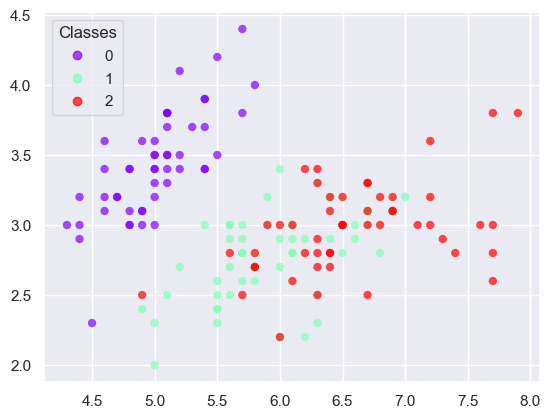

In [806]:
iris = datasets.load_iris()
iris_x = np.array(iris.data[:, :2])  # we only take the first two features.
iris_t = np.array(iris.target)

def plot_iris(legend=True, classes=iris_t, target=plt):
    scatter = target.scatter(iris_x[:, 0], iris_x[:, 1], c=classes, alpha=0.7, cmap='rainbow', edgecolor='none')
    if legend:
        legend = target.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
        return (scatter, legend)
    return (scatter, )

plot_iris()

### 3.2) Classification function

write the `k_nearest_classification` function that takes a test data point `x`, training data points `data_x` and their associated classes `data_t`, the neighbours `k` and returns the predicted class for the test point `x`

In [807]:
def k_nearest_classification(x, data_x, data_t, k):
    # Så hvad? 
    # Givet et test punkt x find 
        # Indeks I til De k antal nærmeste punkter 
        # Med I lav majoritets valg. np.unique(data_t[I], counts = True)
   
    dist = data_x - x
    dist = np.linalg.norm(dist, axis = 1)
    I = np.argsort(dist, axis = 0)[:k]
    
    # Udvælg klasser 
    klasser = data_t[I]
    values, count = np.unique(klasser, return_counts = True)
    return values[np.argmax(count)]

### 3.3) Display results

Display the classification results for different values of `K`

In [808]:
def plot_mesh(pred_fn, n_class=3, x_min=4, x_max=8, y_min=2, y_max=4.5, target=plt):
    h = 0.1  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = np.array(list(map(lambda x: pred_fn(np.array(x)), np.c_[xx.ravel(), yy.ravel()])))
    Z = Z.reshape(xx.shape)
    cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))
    target.axis('tight')
    if hasattr(target, 'xlim'):
        target.xlim(x_min, x_max)
        target.ylim(y_min, y_max)

/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_95433/3786169586.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


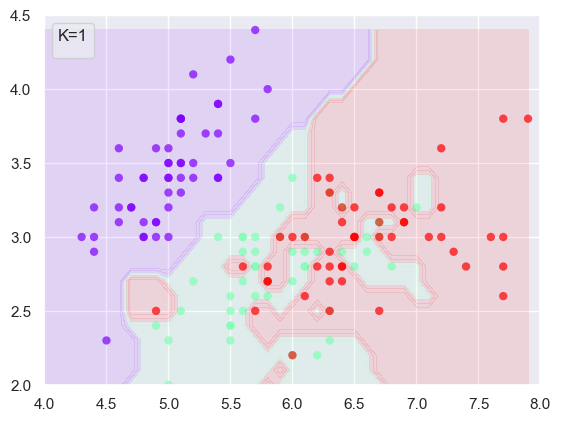

In [809]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 1))
plt.legend([], loc="upper left", title="K=1")

/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_95433/3786169586.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


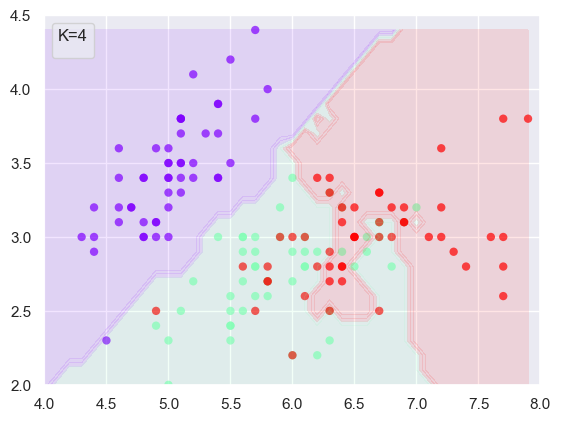

In [810]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 4))
plt.legend([], loc="upper left", title="K=4")

/var/folders/s1/8pjch1gd44lcppl6nnk77kdh0000gn/T/ipykernel_95433/3786169586.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs = target.contourf(xx, yy, Z, alpha = 0.1, cmap=plt.cm.get_cmap('rainbow', n_class))


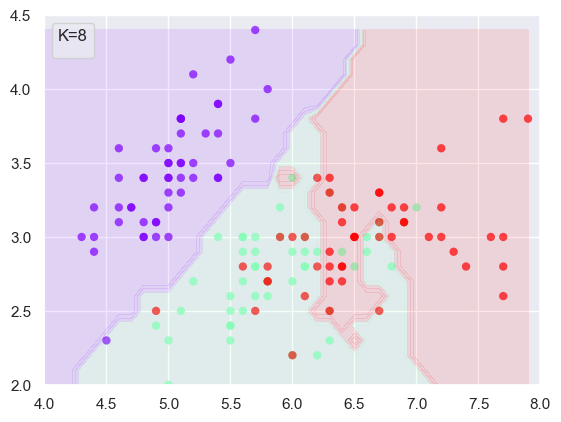

In [811]:
plot_iris(False)
plot_mesh(lambda x: k_nearest_classification(x, iris_x, iris_t, 8))
plt.legend([], loc="upper left", title="K=8")

## 4) K-Means clustering

In [812]:
def k_means_step(mus_0, data_x):
    K, _ = mus_0.shape
    # Mu_0 in R^(k, D)
    # data_x in R^(N, D) 
    t = []
    # t(x)
    for x in data_x:
        # x in R^(D,) 
        # Mu_0 - x in R^(k, D) 
        dist = mus_0 - x
        dist = np.linalg.norm(dist, axis = 1)**2    # R^(k,)
        t.append(np.argmin(dist))                   # R^(N,)
        # print(t)
    t = np.array(t)
    
    # mu(x|t) in R^(k, D) 
    
    # For hver klasse, find indeks i data_x som tilhører den. 
    I = np.argsort(t)
    values, counts = np.unique(t, return_counts = True)
    mu = mus_0 
    
    
    
    
    for k, (value, count) in enumerate(zip(values, counts)): 
        punkter = data_x[t == k]
        if len(punkter) > 0: 
            
            # punkter = list(islice(data, count))  # Tag de næste count antal punkter fra x. data_x[I][0:88], data_x[I][88:137], data_x[I][137:150]
            mu[k] = np.mean(punkter)        
    return (mu, t)

write the `k_means_step` function that takes initial means vector `mus_0`, input data points `data_x` and returns the new means `mus` and `classes` after running a SINGLE ITERATION of the K-means algorithm

Write a function k_means_step(mus_0, data_x) that performs one iteration of the K-means algorithm:

    Assign each data point in data_x to the closest mean in mus_0.

    Compute the new cluster means as the average of the points assigned to each cluster.

    Return the updated means mus and the cluster assignments classes.

Write a function distortion_measure(mus, classes, data_x) that computes the distortion (the K-means objective value):

    For each data point in data_x, find the mean in mus that it was assigned to (given by classes).

    Compute the squared distance between the point and its assigned mean.

    Sum these squared distances over all points.

The function should return this total sum, which is the distortion of the current clustering (see slide 8 of Lecture 8).

In [813]:
def distortion_measure(mus, classes, data_x):
    # Så hvad? 
    # mus in R^(k, D) 
    # data_x in R^(N, D) 
    # dist += √(mus[classes[i]]) - data_x[i] in R^(1, D)) in R^(1) 
    
    mu_n = mus[classes] # Finder mu for hvert punkt 
    dist = 0
    dist = data_x - mu_n
    # dist = np.sqrt(np.outer(dist, dist)) # √(a_i^2 + b_i^2)
    # print(dist.shape)
    dist = np.linalg.norm(dist, axis = 1)**2 
    dist = np.sum(dist)
    return dist

# mus_0
# mu, t = k_means_step(mus_0, iris_x)
# distortion_measure(mu, t, iris_x)

Write a function optimize_k_means(mus_0, data_x) that runs the K-means algorithm until convergence:

    Start from the initial means mus_0.

    Repeatedly apply k_means_step to update cluster assignments and means.

    Stop when the assignments no longer change.

    Return the final means mus and assignments classes.

In [814]:
def optimize_k_means(mus_0, data_x):
    threshold = 0.00025              # Hvis min fejl ikke ændre sig med mere end 0.0025, så tænker jeg, at den er konvergeret. 
    run = True
    mu = mus_0
    t = np.zeros(data_x.shape[0])
    Error = 0
    j = 0                           # Iteration tæller
    while run == True:      
        mu, t = k_means_step(mu, data_x)
        J = distortion_measure(mu, t, data_x)   # J_new
        print(J, Error)
        if np.abs(J - Error) < threshold:             # J_new - J_old < threshold ? 
            run = False
        Error = J                               # J_old = J_new 
        j += 1
    print(j)
    return (mu, t)
# optimize_k_means(mus_0, iris_x)

Apply K-means on IRIS data

In [815]:
k = 3
mus_0 = iris_x[:k]                 # first k points as initial centers
mus, classes = optimize_k_means(mus_0, iris_x)

676.247106688286 0
664.7887440302604 676.247106688286
662.1067489603631 664.7887440302604
661.0780637676793 662.1067489603631
660.7243255333503 661.0780637676793
660.7242904883401 660.7243255333503
6


Plot the input IRIS data along with the final cluster centers 

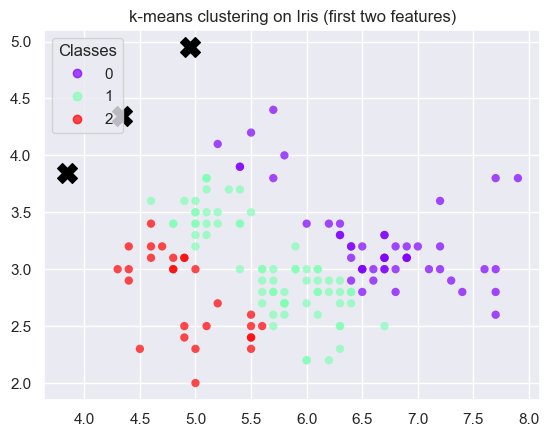

In [816]:
plt.figure()
plot_iris(legend=True, classes=classes)   # use k-means cluster assignments
plt.scatter(mus[:, 0], mus[:, 1], marker='X', s=200, c='black')  # mark centers
plt.title("k-means clustering on Iris (first two features)")
plt.show()

## Konklusion
Jeg tror måske at jeg laver min t forkert, og at det er med til at påvirke mit slut resultat.


### Optional Exercise: Plot the progression of cluster means

Modify your K-means implementation so that after each iteration, you store the current means. Then, create a plot that shows how the cluster centers move step by step until convergence.

Hints:

Keep a list of means after each iteration.

Use scatter plots of the data points and plot the cluster centers (e.g. with X markers).

You may use different colors or arrows to show the trajectory of each cluster center.